In [1]:
#the company should focus more on mobile app or website?
#download dataset from here = https://drive.google.com/file/d/1Rq-XGni73WV7HyqAFqcbCZT00tRKEXa2/view?usp=sharing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [3]:
customers = pd.read_csv('Ecommerce Customers.csv')
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [8]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


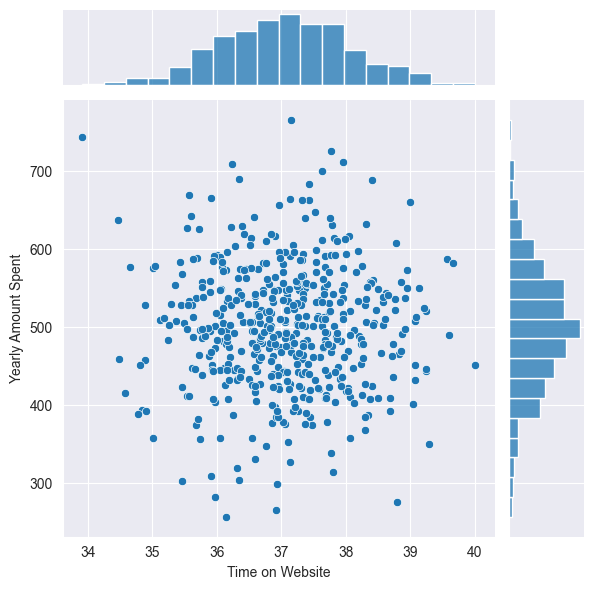

In [10]:
#make joint plot with time on website and yearly amount spent
sns.jointplot(x = 'Time on Website', y = 'Yearly Amount Spent', data = customers)

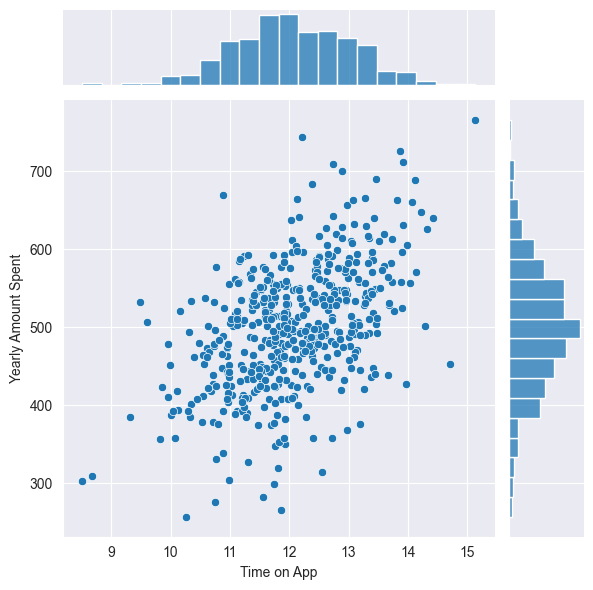

In [11]:
#make the same plot but with time on app instead
sns.jointplot(x = 'Time on App', y = 'Yearly Amount Spent', data = customers)

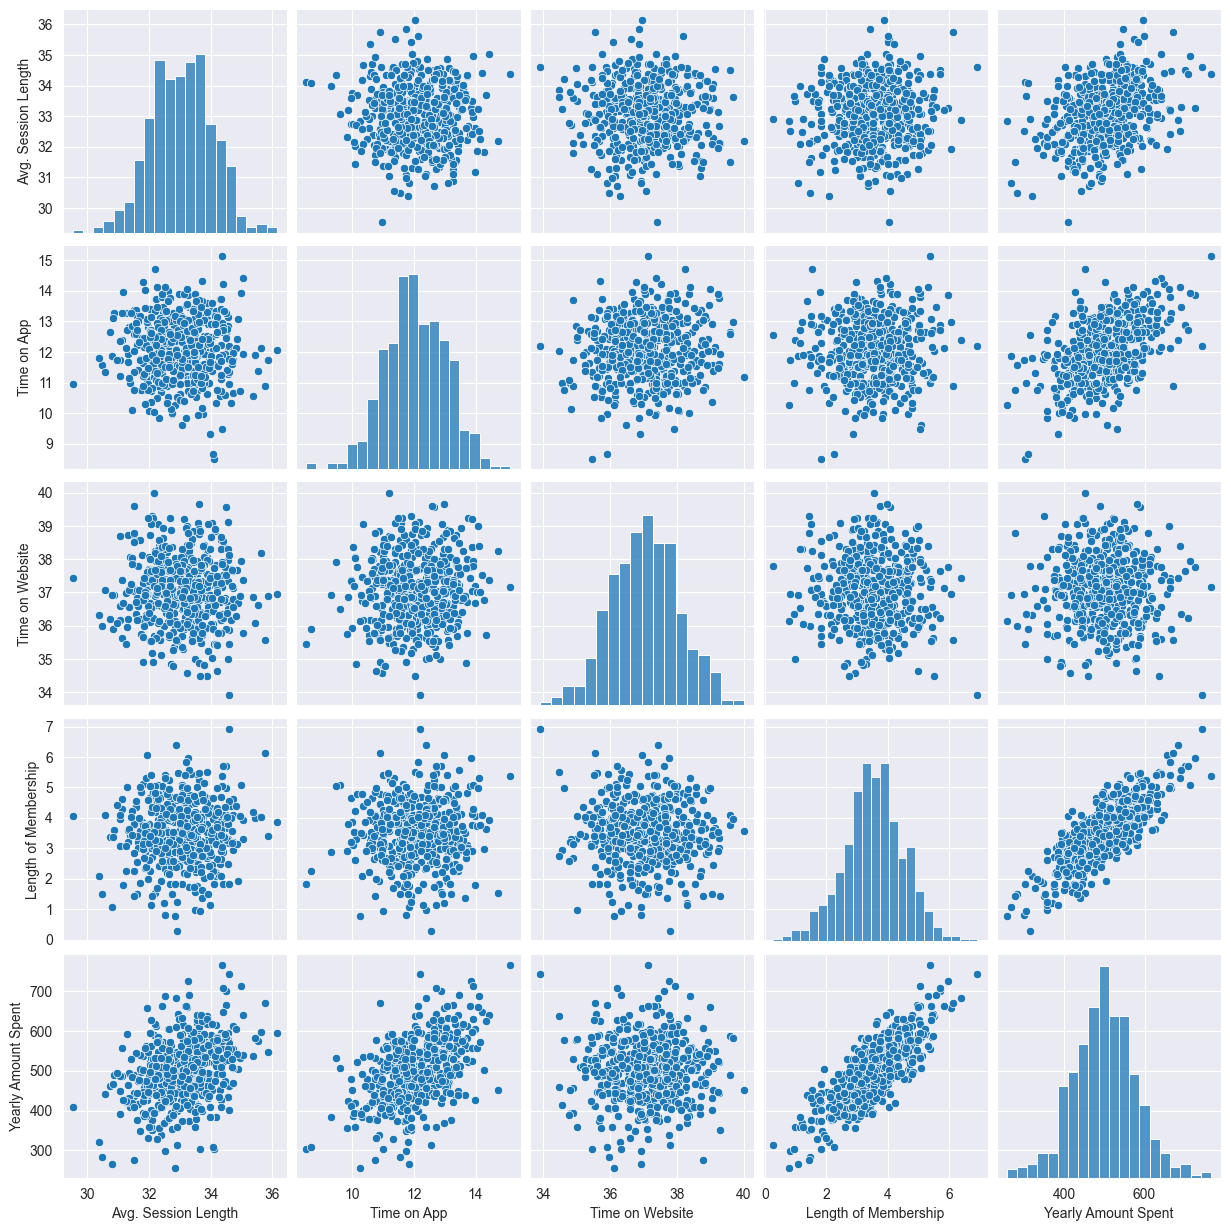

In [12]:
#make a pairplot
sns.pairplot(customers)

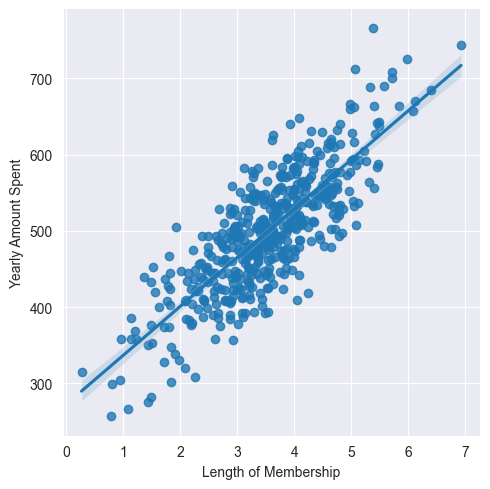

In [4]:
#create linear model plot of yearly amount spent vs length of membership
sns.lmplot(x = 'Length of Membership', y = 'Yearly Amount Spent', data = customers)

In [8]:
#defining x and y:
x = customers[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

In [9]:
#spliting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [10]:
#create ai model:
model = LinearRegression()

In [11]:
#train ai model by giving it training data:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
#printing slope:
model.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [12]:
#test ai model by giving it testing data:
predictions = model.predict(x_test)

Text(0, 0.5, 'predicted values')

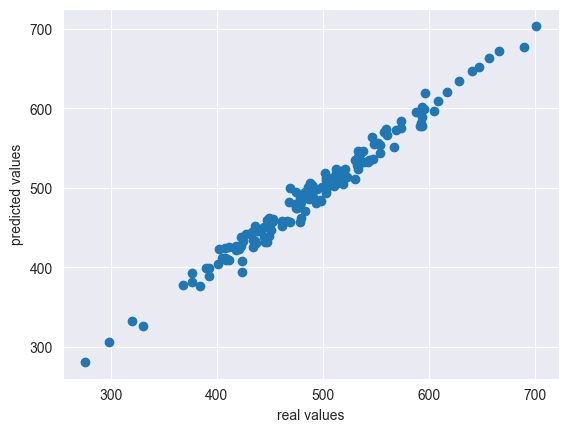

In [17]:
#create scatter plot of real values vs predicted values:
plt.scatter(x = y_test, y = predictions)
plt.xlabel('real values')
plt.ylabel('predicted values')

In [23]:
#evaluating ai model with mae, mse and rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

print(f'MAE Percentage: {(mae / y.mean()) * 100}')
print(f'RMSE Percentage: {(rmse / y.mean()) * 100}')

MAE: 8.426091641432116
RMSE: 10.193897260863155
MAE Percentage: 1.6875334951164171
RMSE Percentage: 2.041580344188885


<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

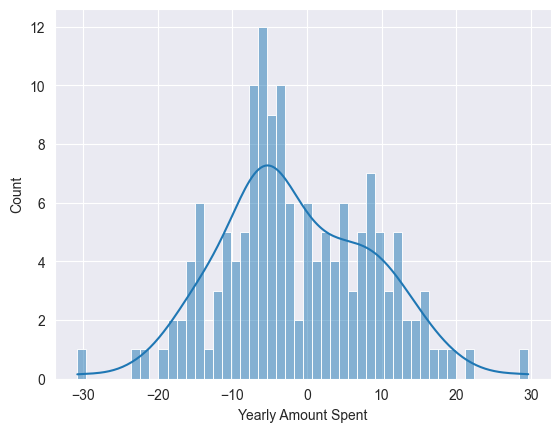

In [27]:
#residuals = y_test - predictions
sns.histplot(y_test - predictions, kde = True, bins = 50)

In [32]:
#consluion?
#should we focus on mobile app development or website development?
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficients'])

,Coefficients
Avg. Session Length,25.724256
Time on App,38.597135
Time on Website,0.459148
Length of Membership,61.674732


Conclusion = company should focus on its app instead of website